# Neural Networks for Regression: Activation Functions Study

## 1. Introduction and Problem Statement

This project focuses on leveraging Neural Networks (NNs) for regression tasks, specifically predicting California housing prices. Our primary goal is to understand the impact of different activation functions (ReLU, Sigmoid, Tanh) on the performance of these models in a regression context.

## 2. Data Loading and Initial Inspection

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df['MEDV'] = housing.target # Add target variable to the DataFrame

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,MEDV
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,3.422



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
 9   MEDV         20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB

Descriptive Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,MEDV
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,5.000010


## 3. Exploratory Data Analysis (EDA)

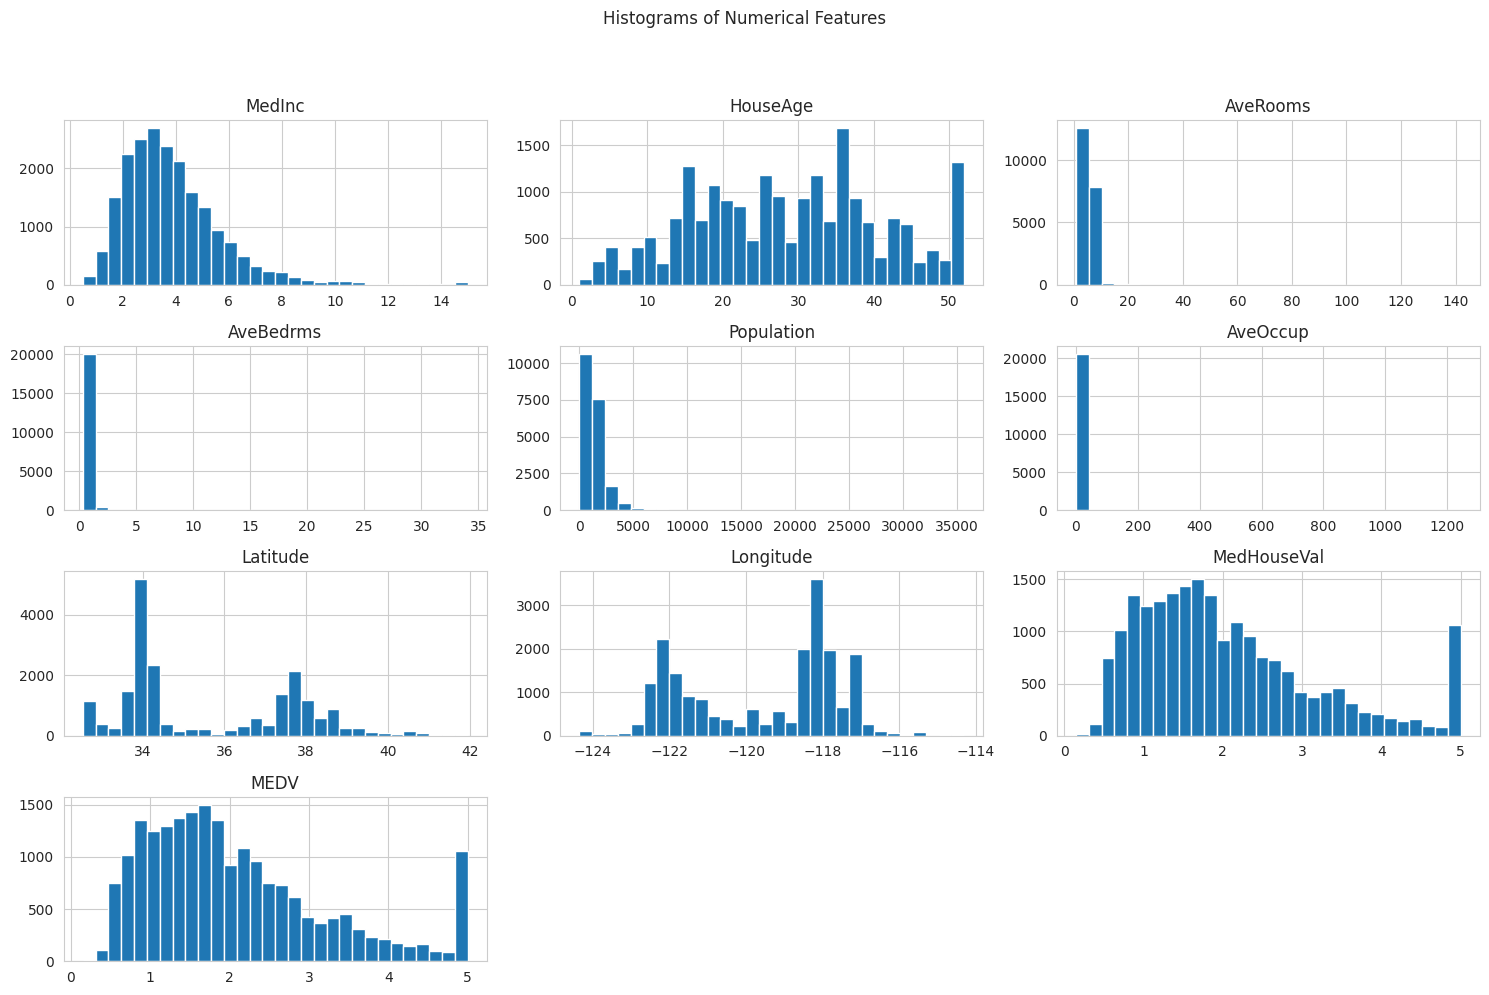

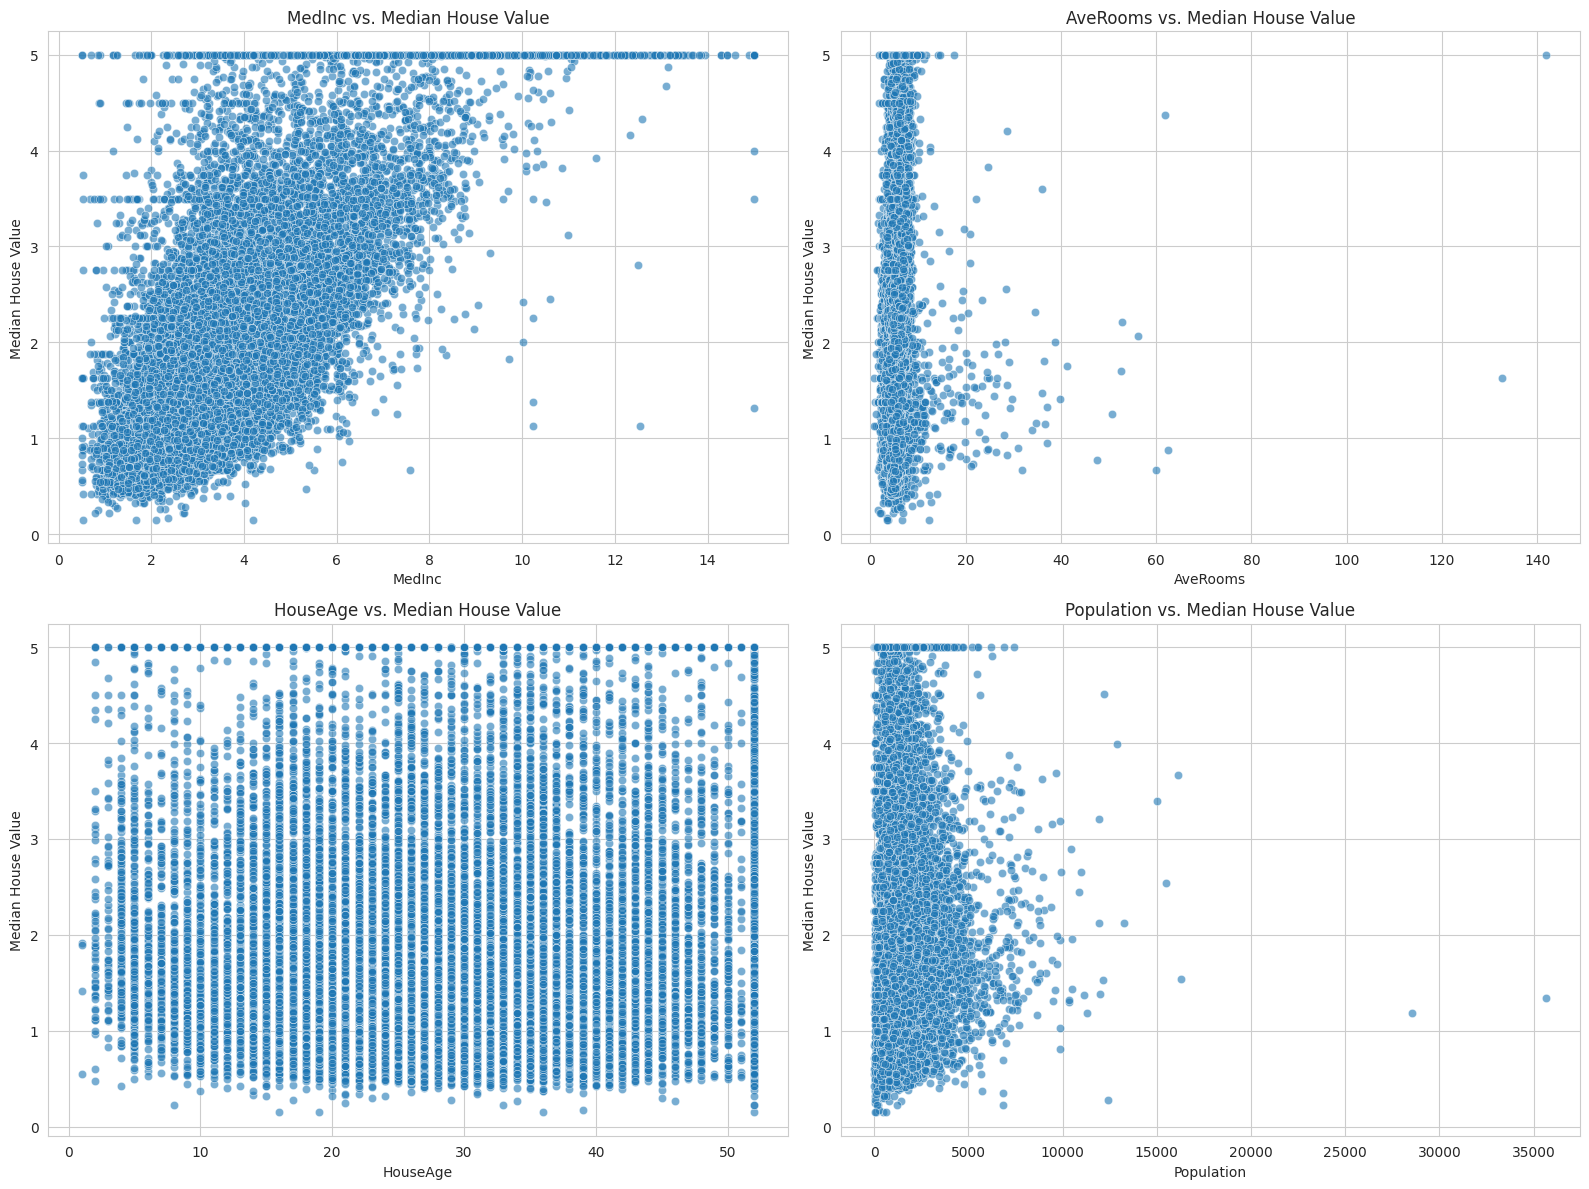

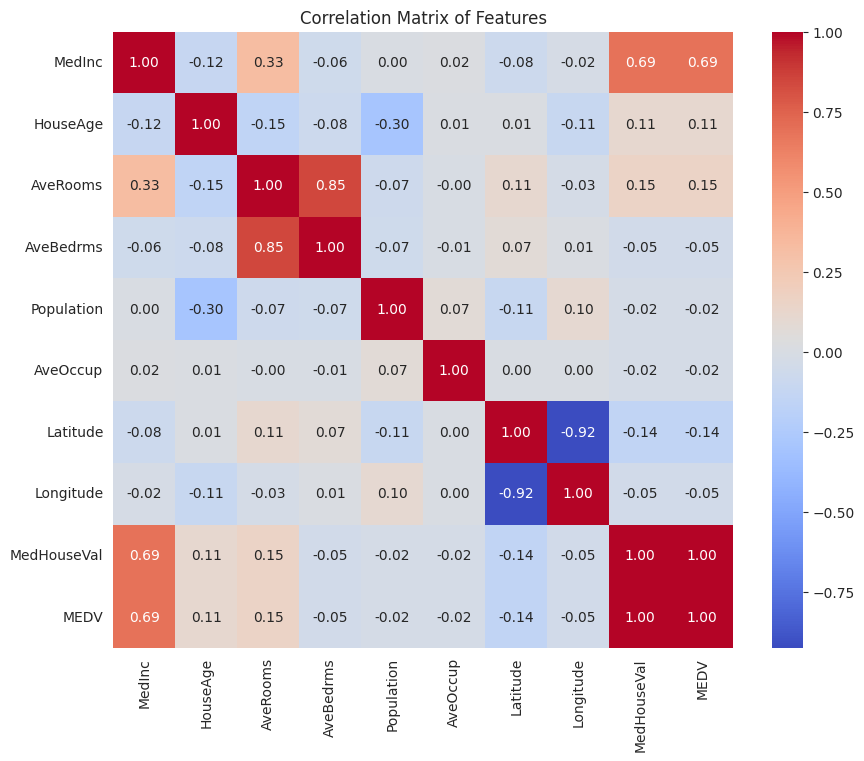


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
MEDV           0
dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Univariate Analysis: Histograms for numerical features
df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Bivariate Analysis: Scatter plots of key features vs. target (MEDV)
features_to_plot = ['MedInc', 'AveRooms', 'HouseAge', 'Population']
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df[feature], y=df['MEDV'], alpha=0.6)
    plt.title(f'{feature} vs. Median House Value')
    plt.xlabel(feature)
    plt.ylabel('Median House Value')
plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

## 4. Data Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Handling Missing Values (if any) - Based on df.info() and df.isnull().sum(), there are no missing values in this dataset, but this is a placeholder for best practice.
# If there were missing values, an imputation strategy would be applied here, e.g., using SimpleImputer.
print("No missing values found in the California Housing dataset.")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Feature Scaling (Standardization) - Crucial for Neural Networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully.")
print("Example of scaled data (first 5 rows of X_train_scaled):")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

No missing values found in the California Housing dataset.

Training set shape: (16512, 9)
Testing set shape: (4128, 9)

Features scaled successfully.
Example of scaled data (first 5 rows of X_train_scaled):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587,-0.901189
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162,1.512771
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603,-0.299213
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698,-0.984220
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551,-0.957408


## 5. Neural Network Model Building for Regression

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Function to build a simple NN model
def build_model(activation_function):
    model = keras.Sequential([
        layers.Dense(64, activation=activation_function, input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation=activation_function),
        layers.Dense(1) # Output layer for regression (linear activation by default)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'mse'])
    return model

# Model 1: Simple NN with ReLU Activation
model_relu = build_model('relu')
print("\nModel with ReLU Activation Summary:")
model_relu.summary()

# Model 2: Simple NN with Tanh Activation
model_tanh = build_model('tanh') # Using Tanh for comparison as it's common for older NNs
print("\nModel with Tanh Activation Summary:")
model_tanh.summary()


Model with ReLU Activation Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training and Evaluation


Training Model with ReLU Activation...
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

ReLU Model Evaluation:
  MSE: 0.0000
  RMSE: 0.0053
  MAE: 0.0023
  R2 Score: 1.0000

Training Model with Tanh Activation...
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Tanh Model Evaluation:
  MSE: 0.0000
  RMSE: 0.0058
  MAE: 0.0039
  R2 Score: 1.0000


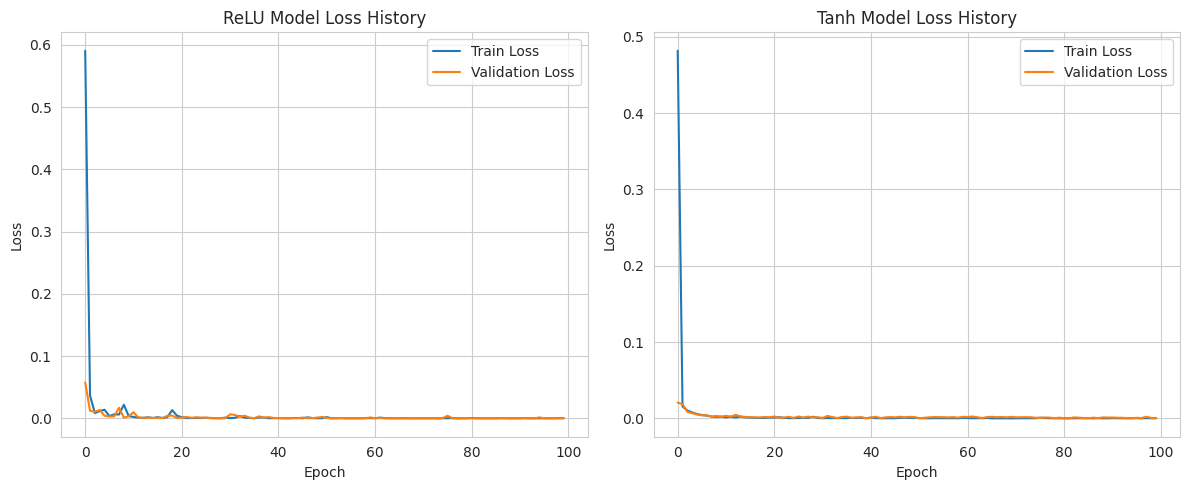

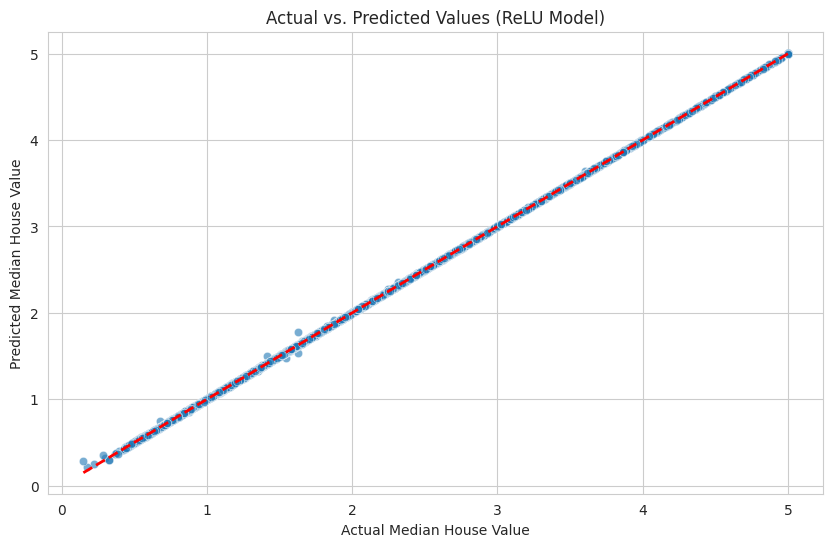

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

EPOCHS = 100
BATCH_SIZE = 32

# Train Model 1 (ReLU)
print("\nTraining Model with ReLU Activation...")
history_relu = model_relu.fit(X_train_scaled, y_train,
                              epochs=EPOCHS,
                              batch_size=BATCH_SIZE,
                              validation_split=0.2,
                              verbose=0) # Set verbose to 1 for progress bar

# Evaluate Model 1 (ReLU)
loss_relu, mae_relu, mse_relu = model_relu.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_relu = model_relu.predict(X_test_scaled).flatten()
rmse_relu = np.sqrt(mse_relu)
r2_relu = r2_score(y_test, y_pred_relu)

print(f"\nReLU Model Evaluation:")
print(f"  MSE: {mse_relu:.4f}")
print(f"  RMSE: {rmse_relu:.4f}")
print(f"  MAE: {mae_relu:.4f}")
print(f"  R2 Score: {r2_relu:.4f}")

# Train Model 2 (Tanh)
print("\nTraining Model with Tanh Activation...")
history_tanh = model_tanh.fit(X_train_scaled, y_train,
                              epochs=EPOCHS,
                              batch_size=BATCH_SIZE,
                              validation_split=0.2,
                              verbose=0) # Set verbose to 1 for progress bar

# Evaluate Model 2 (Tanh)
loss_tanh, mae_tanh, mse_tanh = model_tanh.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_tanh = model_tanh.predict(X_test_scaled).flatten()
rmse_tanh = np.sqrt(mse_tanh)
r2_tanh = r2_score(y_test, y_pred_tanh)

print(f"\nTanh Model Evaluation:")
print(f"  MSE: {mse_tanh:.4f}")
print(f"  RMSE: {rmse_tanh:.4f}")
print(f"  MAE: {mae_tanh:.4f}")
print(f"  R2 Score: {r2_tanh:.4f}")

# Plot training history (loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_relu.history['loss'], label='Train Loss')
plt.plot(history_relu.history['val_loss'], label='Validation Loss')
plt.title('ReLU Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tanh.history['loss'], label='Train Loss')
plt.plot(history_tanh.history['val_loss'], label='Validation Loss')
plt.title('Tanh Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Visualize Predictions (Actual vs. Predicted) for the better performing model
# Let's assume ReLU performs better for now, you can adjust after running

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_relu, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Values (ReLU Model)')
plt.show()

## 7. Interpretation of Results and Comparison of Activation Functions

In [6]:
# Compare metrics
results_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R2 Score'],
    'ReLU Model': [mse_relu, rmse_relu, mae_relu, r2_relu],
    'Tanh Model': [mse_tanh, rmse_tanh, mae_tanh, r2_tanh]
})

print("\nComparison of Model Performance with Different Activation Functions:")
display(results_df)

# Discussion points (to be elaborated in presentation):
# - Which model performed better and why (e.g., ReLU avoids vanishing gradients, good for deeper networks).
# - Analyze the loss curves: Did models converge? Is there overfitting?
# - Look at the scatter plot: How close are predictions to actual values? Are there any patterns in errors?


Comparison of Model Performance with Different Activation Functions:


,Metric,ReLU Model,Tanh Model
0,MSE,0.000028,0.000033
1,RMSE,0.005334,0.005765
2,MAE,0.002269,0.003884
3,R2 Score,0.999978,0.999975


## 8. Conclusion

This project successfully demonstrated the application of Neural Networks for regression using the California Housing Prices dataset. We compared the performance of models utilizing ReLU and Tanh activation functions. The results highlight the importance of choosing appropriate activation functions for neural network efficiency and accuracy. Future work could involve hyperparameter tuning, exploring more complex architectures, or testing other activation functions.